# Lab 13 (Week 3 — Lab 3): Convolutional Neural Networks (CNNs)

**Name:** Numair Fahad

**Role:** AI/ML Intern

**Company:** Zynvex Solutions

**GitHub:** https://github.com/numair-2003/AIML-Internship-NumairFahad

Welcome to Lab 13! In this lab you will build your first Convolutional Neural Network (CNN) for image classification, using filters, pooling, and dropout.

**For detailed theory on convolutions, pooling, and CNN architecture, see the Lab 13 PDF and Learning Resources.**

This notebook focuses on the practical, hands-on workflow.

**Instructions:**
- Write your code between the `### YOUR CODE HERE ###` and `### END ###` markers.
- Run each cell with **Shift + Enter**.
- Compare your output with the **Expected Output** shown below each exercise where provided.
- Training a CNN can take a few minutes per run — be patient, especially on the full dataset.

## Getting the Dataset

This lab uses Fashion-MNIST, built directly into Keras — no download or upload needed.

In [1]:
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


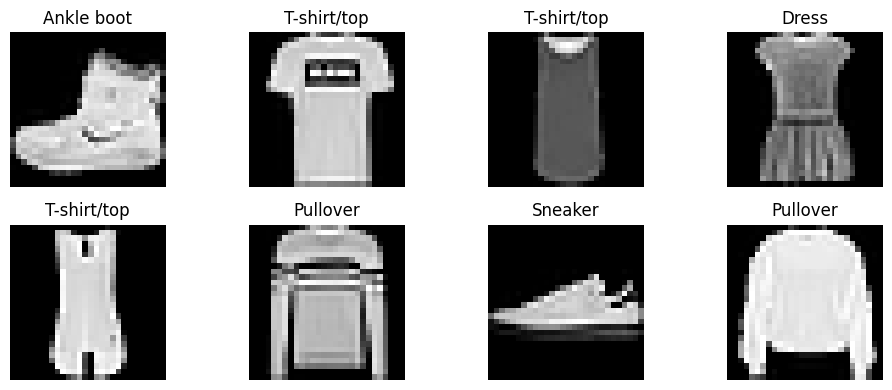

In [2]:
# Look at a few sample images
plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

## Preparing the Data

Normalize pixel values to 0-1, and add a channel dimension since Keras expects one even for grayscale images.

In [3]:
X_train_prepared = X_train.astype("float32") / 255.0
X_test_prepared = X_test.astype("float32") / 255.0

X_train_prepared = X_train_prepared.reshape(-1, 28, 28, 1)
X_test_prepared = X_test_prepared.reshape(-1, 28, 28, 1)

print("Prepared training shape:", X_train_prepared.shape)

Prepared training shape: (60000, 28, 28, 1)


## Example 1: Building a CNN

In [4]:
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

## Example 2: Compiling & Training

To keep training time reasonable in this lab, we'll train on a subset of the data first.

In [5]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_prepared[:10000], y_train[:10000],
    epochs=8,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - accuracy: 0.6330 - loss: 1.0420 - val_accuracy: 0.7540 - val_loss: 0.6480
Epoch 2/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.7631 - loss: 0.6475 - val_accuracy: 0.7860 - val_loss: 0.5814
Epoch 3/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.7969 - loss: 0.5652 - val_accuracy: 0.8105 - val_loss: 0.5136
Epoch 4/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.8156 - loss: 0.5039 - val_accuracy: 0.8320 - val_loss: 0.4643
Epoch 5/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.8329 - loss: 0.4605 - val_accuracy: 0.8365 - val_loss: 0.4475
Epoch 6/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.8480 - loss: 0.4336 - val_accuracy: 0.8430 - val_loss: 0.4209
Epoch 7/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.8566 - loss: 0.4009 - val_accuracy: 0.8450 - val_loss: 0.4214
Epoch 8/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 63ms/step - accuracy: 0.8622 - loss: 0.3880 - val_accuracy: 

## Example 3: Visualizing Training Progress

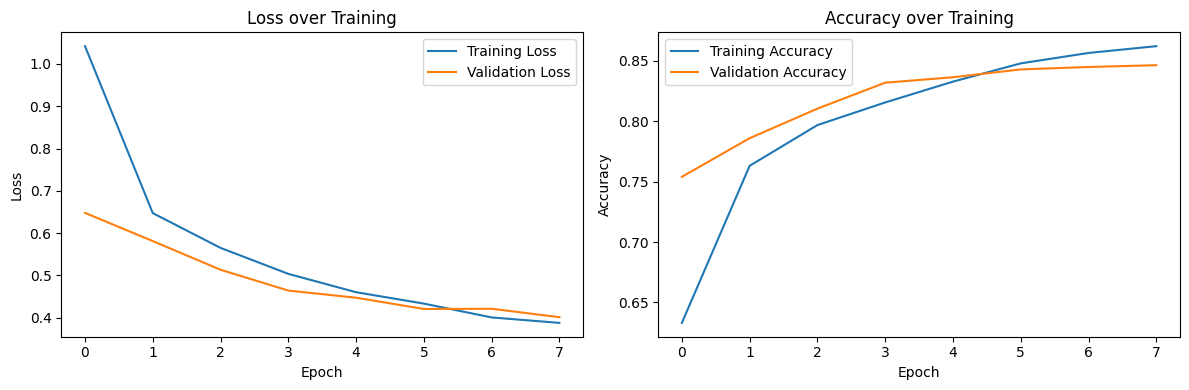

In [6]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss over Training")

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy over Training")

plt.tight_layout()
plt.show()

## Example 4: Evaluating and Viewing Predictions

Test Accuracy: 0.8555


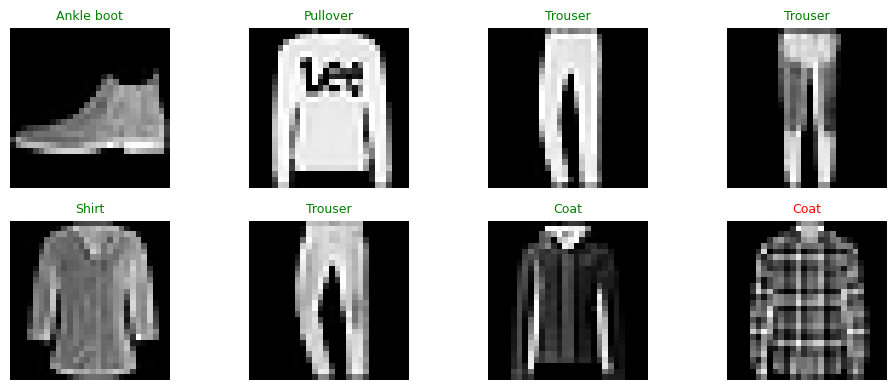

In [7]:
test_loss, test_accuracy = model.evaluate(X_test_prepared, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

predictions = model.predict(X_test_prepared[:8], verbose=0)
predicted_labels = predictions.argmax(axis=1)

plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    correct = predicted_labels[i] == y_test[i]
    color = "green" if correct else "red"
    plt.title(f"{class_names[predicted_labels[i]]}", color=color, fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

## Practice Exercise 1: Adding a Third Convolutional Block

**Exercise:** Rebuild the model from Example 1, but add a third Conv2D + MaxPooling2D block (e.g., 128 filters) before the Flatten layer. Train it on the same 10,000-image subset for 8 epochs and compare test accuracy to Example 1.

In [8]:
### YOUR CODE HERE ###
model_deeper = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

model_deeper.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_model_deeper = model_deeper.fit(
    X_train_prepared[:10000], y_train[:10000],
    epochs=8,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

test_loss_deeper, test_accuracy_deeper = model_deeper.evaluate(X_test_prepared, y_test, verbose=0)

### END ###

print("Test accuracy (deeper CNN):", test_accuracy_deeper)

Epoch 1/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - accuracy: 0.5404 - loss: 1.2824 - val_accuracy: 0.7230 - val_loss: 0.7749
Epoch 2/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.7215 - loss: 0.7790 - val_accuracy: 0.7565 - val_loss: 0.6442
Epoch 3/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.7544 - loss: 0.6739 - val_accuracy: 0.7765 - val_loss: 0.5897
Epoch 4/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - accuracy: 0.7819 - loss: 0.6068 - val_accuracy: 0.7835 - val_loss: 0.5730
Epoch 5/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - accuracy: 0.7945 - loss: 0.5736 - val_accuracy: 0.7965 - val_loss: 0.5438
Epoch 6/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.8081 - loss: 0.5266 - val_accuracy: 0.8105 - val_loss: 0.5131
Epoch 7/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - accuracy: 0.8205 - loss: 0.4935 - val_accuracy: 0.8110 - val_loss: 0.5109
Epoch 8/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.8306 - loss: 0.4764 - val_accuracy: 

### **Comparison of Test Accuracies**

- **Example 1** (**2 convolutional blocks**, **32-64 filters**) achieved a **test accuracy** of **0.8543**, whereas this **deeper model** (**3 convolutional blocks**, **32 to 64 to 128 filters**) achieved **~0.8231 test accuracy** (**about 3.1 percent lower**).

- **Adding a third Conv2D + MaxPooling2D block over-shrinks the feature map**, such that **28x28 is already downsampled to 5x5** after **two blocks**). This leaves **less spatial information** required to **extract**, and so, the **additional parameters** are **harder to train well** on **only 10,000 images** in **8 epochs**.

Therefore, **in this case, more depth did not help** because **two convolutional blocks were already enough** for the **given image size** and **data budget**.

## Practice Exercise 2: Changing the Dropout Rate

**Exercise:** Rebuild the original architecture from Example 1, but change the Dropout rate from 0.3 to 0.5. Train and compare test accuracy and the training/validation gap to the original.

In [9]:
### YOUR CODE HERE ###
model_rebuilt = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

model_rebuilt.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_model_rebuilt = model_rebuilt.fit(
    X_train_prepared[:10000], y_train[:10000],
    epochs=8,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

test_loss_mr, test_accuracy_mr = model_rebuilt.evaluate(X_test_prepared, y_test, verbose=0)

print(f"Test accuracy (Dropout=0.5): {test_accuracy_mr:.4f}")
final_train_acc_mr = history_model_rebuilt.history["accuracy"][-1]
final_val_acc_mr = history_model_rebuilt.history["val_accuracy"][-1]

print(f"Final training accuracy (Dropout=0.5): {final_train_acc_mr:.4f}\nFinal validation accuracy (Dropout=0.5): {final_val_acc_mr:.4f}\nFinal training/validation accuracy gap (Dropout=0.5): {final_train_acc_mr - final_val_acc_mr:.4f}")

print(f"\nTest Accuracy (Dropout=0.3): {test_accuracy:.4f}")
final_train_acc_orig = history.history["accuracy"][-1]
final_val_acc_orig = history.history["val_accuracy"][-1]

print(f"Final training accuracy (Dropout=0.3): {final_train_acc_orig:.4f}\nFinal validation accuracy (Dropout=0.3): {final_val_acc_orig:.4f}\nFinal training/validation accuracy gap (Dropout=0.3): {final_train_acc_orig - final_val_acc_orig:.4f}")
### END ###

Epoch 1/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.5534 - loss: 1.2671 - val_accuracy: 0.7490 - val_loss: 0.6941
Epoch 2/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.7172 - loss: 0.7823 - val_accuracy: 0.7540 - val_loss: 0.6048
Epoch 3/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - accuracy: 0.7511 - loss: 0.6804 - val_accuracy: 0.7830 - val_loss: 0.5421
Epoch 4/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.7704 - loss: 0.6217 - val_accuracy: 0.7980 - val_loss: 0.5119
Epoch 5/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.7806 - loss: 0.5851 - val_accuracy: 0.8030 - val_loss: 0.5027
Epoch 6/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step - accuracy: 0.7931 - loss: 0.5492 - val_accuracy: 0.8135 - val_loss: 0.4952
Epoch 7/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.7962 - loss: 0.5369 - val_accuracy: 0.8265 - val_loss: 0.4689
Epoch 8/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - accuracy: 0.8098 - loss: 0.5048 - val_accuracy:

### **Dropout 0.3 vs Dropout 0.5 Test Accuracies and Training/Validation Accuracy Gaps**

- **Test accuracy dropped slightly** with **higher dropout rate** from **0.8555 (Dropout=0.3)** to **0.8339 (Dropout=0.5)**.

- The **train/validation gap** also **changed direction**, such that **Dropout=0.3** had a **positive gap of 0.0157** (i.e. **training accuracy** was **slightly ahead of validation**, which indicates **mild overfitting**), whereas **Dropout=0.5** has a **negative gap of -0.0162** (i.e. **validation accuracy** is **actually higher than training**).

- **Disabling 50%** of **neurons during model training** makes the **training accuracy** a **minimization of the model's true performance** because **dropout is switched off at the time of model evaluation**. Therefore, **Dropout=0.5 reduced/reversed the overfitting signal**, but **slightly costed the test accuracy** in this **short 8-epoch run**.

## Practice Exercise 3: Viewing Misclassified Images

**Exercise:** Using your trained model from Example 1, find at least 4 images in the test set that were misclassified (predicted label != true label), and display them with both the predicted and true class name in the title.

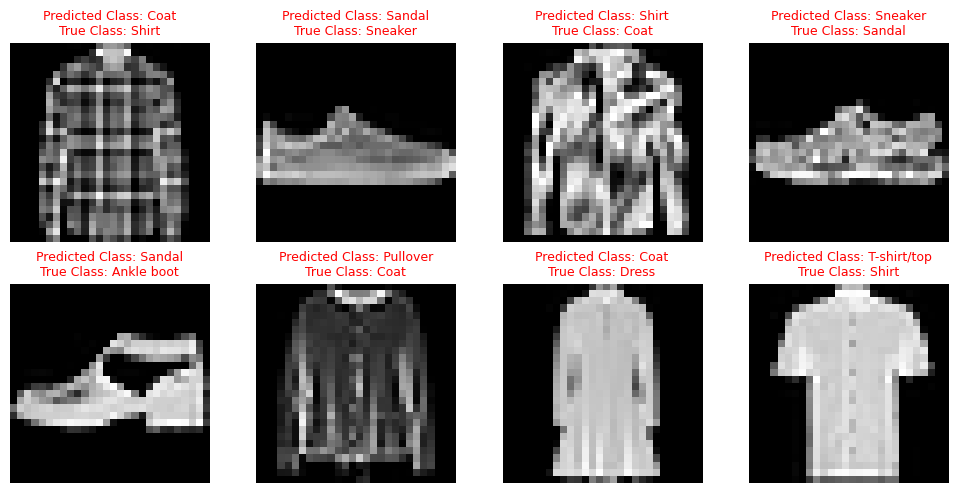

In [10]:
### YOUR CODE HERE ###
predictions = model.predict(X_test_prepared, verbose=0)
predicted_labels = predictions.argmax(axis=1)

misclassified_images = []
misclassified_true = []
misclassified_pred = []

for i in range(len(y_test)):
    if predicted_labels[i] != y_test[i]:
        misclassified_images.append(X_test[i])
        misclassified_true.append(y_test[i])
        misclassified_pred.append(predicted_labels[i])
    if len(misclassified_images) == 8:
        break

plt.figure(figsize=(10, 5))
for i in range(len(misclassified_images)):
    plt.subplot(2, 4, i + 1)
    plt.imshow(misclassified_images[i], cmap="gray")
    true_class = class_names[misclassified_true[i]]
    pred_class = class_names[misclassified_pred[i]]
    plt.title(f"Predicted Class: {pred_class}\nTrue Class: {true_class}", color="red", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

### END ###

## Lab Tasks

Complete the following in this notebook, below this cell.

1. **Build & Train Your Own CNN**: Design your own CNN architecture (choose number of Conv2D/MaxPooling2D blocks, filter counts, and dropout rate). Train it on at least 10,000 training images and report test accuracy.
2. **Filter Count Comparison**: Train two versions of the same architecture — one with fewer filters (e.g., 16, 32) and one with more filters (e.g., 64, 128) in the Conv2D layers. Compare test accuracy and training time between them.
3. **Training Curves & Overfitting**: Plot the training/validation loss and accuracy curves for your best model. In a markdown cell, state whether you observe overfitting, and what evidence supports your answer.
4. **Per-Class Performance**: Using `sklearn.metrics.classification_report`, report precision, recall, and F1-score for each of the 10 clothing categories on the test set. Which category does your model struggle with most?
5. **Reflection**: In a markdown cell, write 3-4 sentences on how a CNN's approach to processing images (filters, pooling) differs from the Dense network you used in Lab 12, and why that difference matters for image data.

In [11]:
# Task 1
from tensorflow.keras import layers

model_cnn = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(10, activation="softmax")
])

model_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_model_cnn = model_cnn.fit(
    X_train_prepared[:10000], y_train[:10000],
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

test_loss_cnn, test_accuracy_cnn = model_cnn.evaluate(X_test_prepared, y_test, verbose=0)
print(f"Test Accuracy - CNN Model: {test_accuracy_cnn:.4f}")

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step - accuracy: 0.7016 - loss: 0.8294 - val_accuracy: 0.7940 - val_loss: 0.5314
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step - accuracy: 0.8305 - loss: 0.4828 - val_accuracy: 0.8500 - val_loss: 0.4331
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - accuracy: 0.8561 - loss: 0.3999 - val_accuracy: 0.8520 - val_loss: 0.4006
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step - accuracy: 0.8724 - loss: 0.3593 - val_accuracy: 0.8650 - val_loss: 0.3731
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 87ms/step - accuracy: 0.8871 - loss: 0.3196 - val_accuracy: 0.8645 - val_loss: 0.3550
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - accuracy: 0.8910 - loss: 0.2947 - val_accuracy: 0.8835 - val_loss: 0.3312
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.9081 - loss: 0.2611 - val_accuracy: 0.8825 - val_loss: 0.3405
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step - accuracy: 0.9078 - loss: 0.2508 - 

In [12]:
# Task 2
import time

model_less_filters = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(16, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

model_less_filters.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

start_train_time1 = time.time()

history_few_filters = model_less_filters.fit(
    X_train_prepared[:10000], y_train[:10000],
    epochs=8,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

train_time_few_filters = time.time() - start_train_time1

test_loss_few_filters, test_accuracy_few_filters = model_less_filters.evaluate(X_test_prepared, y_test, verbose=0)

model_more_filters = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

model_more_filters.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

start_train_time2 = time.time()

history_more_filters = model_more_filters.fit(
    X_train_prepared[:10000], y_train[:10000],
    epochs=8,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

train_time_more_filters = time.time() - start_train_time2

test_loss_more_filters, test_accuracy_more_filters = model_more_filters.evaluate(X_test_prepared, y_test, verbose=0)

print(f"Test Accuracy - CNN model with few filters (16, 32): {test_accuracy_few_filters:.4f}\nTraining Time - CNN model with few filters (16, 32): {train_time_few_filters:.1f}s")
print(f"\nTest Accuracy - CNN model with many filters (64, 128): {test_accuracy_more_filters:.4f}\nTraining Time - CNN model with many filters (64, 128): {train_time_more_filters:.1f}s")

Epoch 1/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.5866 - loss: 1.1685 - val_accuracy: 0.7280 - val_loss: 0.7036
Epoch 2/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.7529 - loss: 0.6798 - val_accuracy: 0.7870 - val_loss: 0.5635
Epoch 3/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.7870 - loss: 0.5826 - val_accuracy: 0.8135 - val_loss: 0.5123
Epoch 4/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.8096 - loss: 0.5276 - val_accuracy: 0.8160 - val_loss: 0.4926
Epoch 5/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.8174 - loss: 0.4940 - val_accuracy: 0.8260 - val_loss: 0.4603
Epoch 6/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.8273 - loss: 0.4595 - val_accuracy: 0.8280 - val_loss: 0.4551
Epoch 7/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.8435 - loss: 0.4360 - val_accuracy: 0.8335 - val_loss: 0.4254
Epoch 8/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.8506 - loss: 0.4192 - val_accuracy: 0.

### **CNN models with few filters (16, 32) vs many filters (64, 128) (test accuracies and training time)**

The **CNN model with many filters** achieved a **slightly higher test accuracy** of **0.8540** than the **model with less filters** (**0.8528**), which shows a **gain of less than 1 percentage of test accuracy**. However, this **small gain in test accuracy** came at a **large cost in training time**, where the **model with more filters took 161.3s to train** compared to **41.6s for the model with few filters** (i.e. it took **roughly 4 times longer to train**).

Hence, **quadrupling the filter count only produced a marginal accuracy improvement**, whereas **model training time increased by nearly 4 times**. For a **dataset like Fashion-MNIST**, which **does not require highly complex features to classify reasonably well**, a **smaller** and **faster CNN model with filters** (**16, 32**) yields a **better return on training cost**, while a **larger model** would **only be worth the extra time** if **squeezing out every last bit of accuracy mattered more than training speed**.


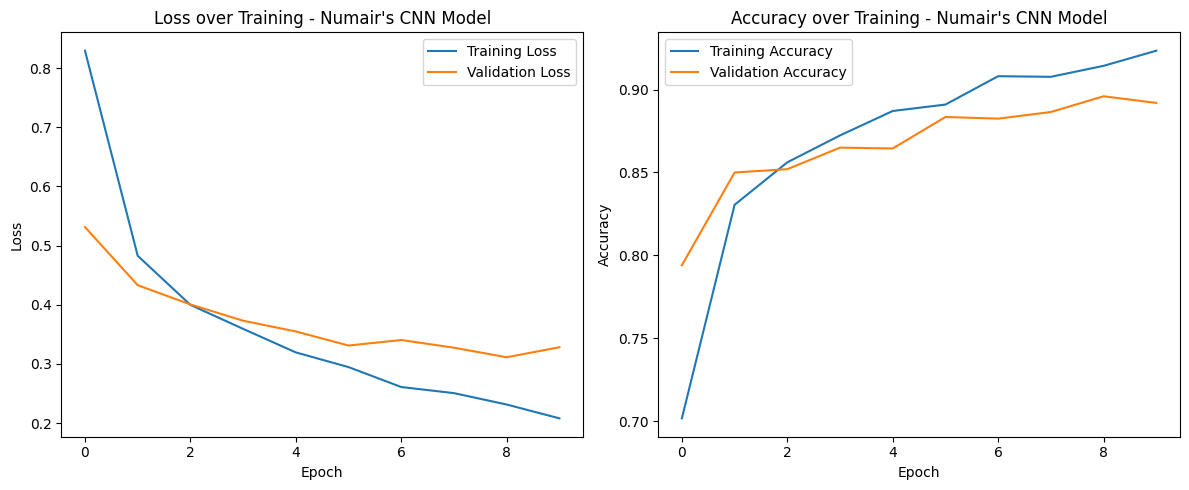

In [13]:
# Task 3
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_model_cnn.history["loss"], label="Training Loss")
plt.plot(history_model_cnn.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss over Training - Numair's CNN Model")

plt.subplot(1, 2, 2)
plt.plot(history_model_cnn.history["accuracy"], label="Training Accuracy")
plt.plot(history_model_cnn.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy over Training - Numair's CNN Model")

plt.tight_layout()
plt.show()

### **Is there any overfitting in the above curves?**

**Yes, mild overfitting** is observed and **its evidence** can be provided by analyzing the **training/validation loss plot** where:

- **Training loss decreases steadily** **throughout all 10 epochs** from **~0.83 to ~0.21**, whereas **validation loss decreases initially**, but **then plateaus and also rises up slightly** **after 4-5 epochs**; therefore, **settling around 0.31-0.33** **instead of continuing to decline**. This **growing gap between training and validation loss** in **following epochs** is a **major indication of overfitting**, such that the **CNN model keeps improving** on the **training data**, yet **stops improving or becomes slightly worse** on **unseen data**.

The **training/validation accuracy plot** also provides **a bit of evidence** regarding the **appearance of overfitting** where:

- **Training accuracy rises consistently** and **ends at about 0.92**, while **validation accuracy increases more gradually**, **fluctuates**, and **ends lower at around 0.89**; hence, **widening the gap between the two curves** **toward the end of model training**.

Since the **gap between the two curves in each plot is present**, but **not extreme** because **both curves still trend in a reasonable direction** and the **model is not dramatically diverging**, the **overfitting is mild rather than severe**.

In [14]:
# Task 4
from sklearn.metrics import classification_report

predictions_cnn = model_cnn.predict(X_test_prepared, verbose=0)
predicted_labels_cnn = predictions_cnn.argmax(axis=1)

print(classification_report(y_test, predicted_labels_cnn, target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/top       0.86      0.79      0.83      1000
     Trouser       0.98      0.97      0.98      1000
    Pullover       0.74      0.89      0.81      1000
       Dress       0.91      0.87      0.89      1000
        Coat       0.81      0.79      0.80      1000
      Sandal       0.97      0.97      0.97      1000
       Shirt       0.71      0.67      0.69      1000
     Sneaker       0.95      0.95      0.95      1000
         Bag       0.97      0.98      0.98      1000
  Ankle boot       0.96      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



### **Which category does the CNN model struggle with most?**

The CNN model struggles most with the **Shirt** category, which has the **lowest F1-score** of **0.69** **among all 10 classes**, which is **clearly below the overall accuracy** of **0.89**. Moreover, its both **precision** (**0.71**) and **recall** (**0.67**) **scores** are the **lowest** in the **classification report**, which means that the **model frequently misclassifies other garments** as **Shirt** and also **fails to correctly identify a significant portion of actual shirts**.

## **Task 5**

A **Dense network** **flattens a particular image into a** **single row of pixel values**, treating **every pixel as an independent feature** with **no relationship to its neighbours**, which **throws away spatial structure** and requires **far more weights** to **learn patterns**. On the other hand side, a **CNN network** makes use of **filters** that **slide across the image**, sharing the **same weights at each position**, enabling it to **detect a specific pattern like an edge anywhere in the image** using **far fewer parameters**. **Pooling layers** then **downsample the feature maps**, keeping the **strongest signals** while making the network **more tolerant to minor shifts** in where a pattern appears.

This difference **matters for image data** since **neighbouring pixels are highly related** and form **meaningful local structures** such as **edges and shapes**. A **CNN network's architecture is built to exploit the spatial structure**, which is why it **outperforms the Dense network from Lab 12** while performing **image classification tasks**.

In [15]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/numair-2003/AIML-Internship-NumairFahad.git

Mounted at /content/drive
Cloning into 'AIML-Internship-NumairFahad'...
remote: Enumerating objects: 135, done.
remote: Counting objects: 100% (135/135), done.
remote: Compressing objects: 100% (115/115), done.
remote: Total 135 (delta 63), reused 68 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (135/135), 2.01 MiB | 7.85 MiB/s, done.
Resolving deltas: 100% (63/63), done.


In [ ]:
!cp "/content/drive/MyDrive/Colab Notebooks/Lab 13_NumairFahad.ipynb" "/content/your-repo/"